#CIFAR w/ PyTorch (CNN)

Project Procedure

- Step1: data load
- Step2: define model v1 (w/o BatchNorm)
- Step3: train() / evaluate()
- Step4: executeTraining Loop v1
- Step5: model v2 - add BatchNorm
- Step6: add LR Scheduler
- Step7: result visualization

##1. Imports

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import matplotlib.pyplot as plt
import numpy as np

##2. Load CIFAR10 Data & Cross-Check

In [ ]:
#image data transform into tensor + normalize
#RGB -> 3 channels now.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465), #mean = images.mean(dim=[0,2,3])
        std = (0.2470, 0.2435, 0.2616) #std = images.std(dim=[0,2,3])
    )
])

#load datasets
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=False, transform=transform)

#CIFAR is pre-splitted into training set(60k images) & test set (10k images)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
#have to shuffle data every epoch during train to prevent model from memorizing the sequence
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)
#no need to update model param -> X have to shuffle as the result stays the same.

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")
print(f"Train Batches: {len(train_loader)}")
print(f"Test Batches: {len(test_loader)}")

#checking shapes
images, labels = next(iter(train_loader))

print(f"Shape of images: {images.shape}")
print(f"Shape of labels: {labels.shape}")
print(f"pixel range  : {images.min():.2f} ~ {images.max():.2f}")

100%|██████████| 170M/170M [00:01<00:00, 107MB/s]


Number of training samples: 50000
Number of test samples: 10000
Train Batches: 782
Test Batches: 157
Shape of images: torch.Size([64, 3, 32, 32])
Shape of labels: torch.Size([64])
pixel range  : -1.99 ~ 2.13


**Q: Why Normalize like this?**
-  If input values are large (e.g., in the range 0–255), gradients can become unstable. Centering the inputs around zero helps stabilize training and makes optimization more effective.
- Each channel should be independently normalized

##3. Data Visualization

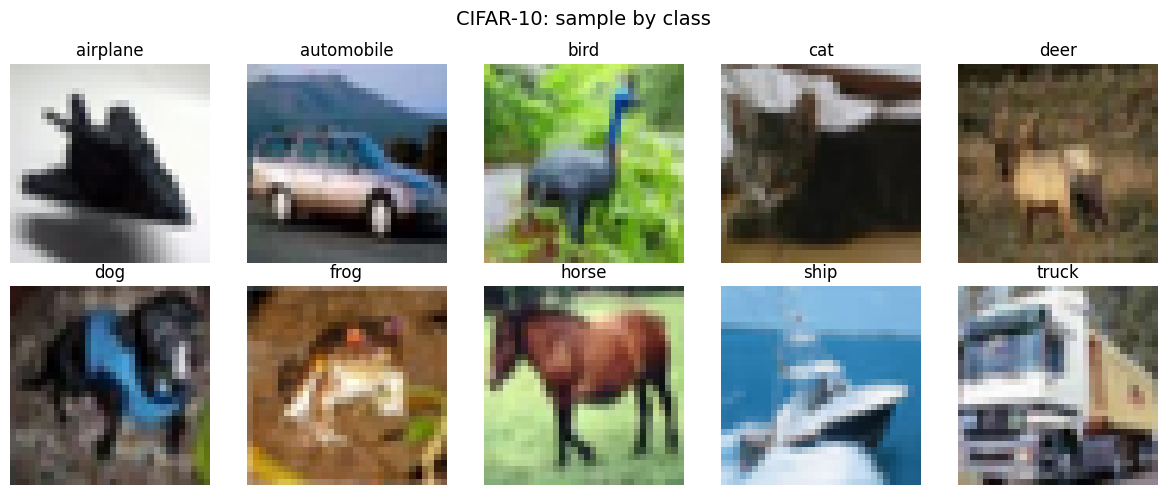

In [ ]:
#sample visualization by class
CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# Denormalize to visualize
def denormalize(tensor):
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)
    std  = torch.tensor([0.2470, 0.2435, 0.2616]).view(3,1,1)
    return (tensor * std + mean).clamp(0, 1)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("CIFAR-10: sample by class", fontsize=14)

shown = {}
idx = 0
while len(shown) < 10:
    img, label = train_dataset[idx]
    if label not in shown:
        shown[label] = (img, label)
    idx += 1

for i, (label, (img, lbl)) in enumerate(sorted(shown.items())):
    ax = axes[i // 5][i % 5]
    ax.imshow(denormalize(img).permute(1, 2, 0))  # (C,H,W) → (H,W,C)
    ax.set_title(CLASS_NAMES[lbl])
    ax.axis('off')

plt.tight_layout()
plt.show()

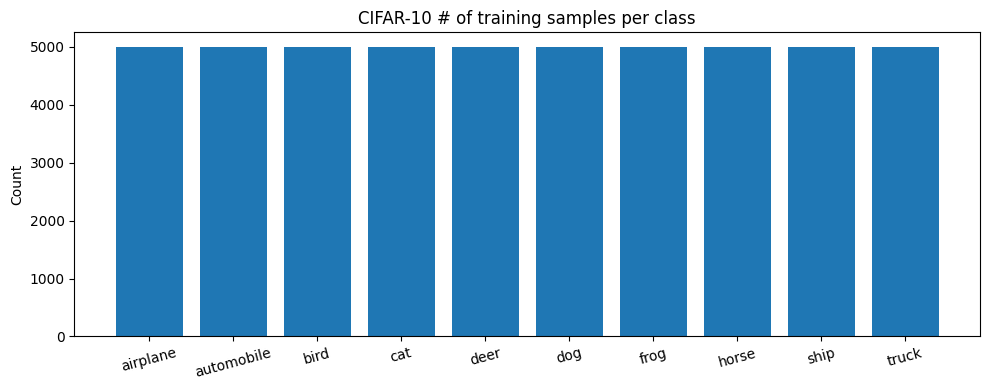

number by class:
  airplane    : 5,000
  automobile  : 5,000
  bird        : 5,000
  cat         : 5,000
  deer        : 5,000
  dog         : 5,000
  frog        : 5,000
  horse       : 5,000
  ship        : 5,000
  truck       : 5,000


In [ ]:
#Check Class Distribution
# Check how many are there for each class
# if there's a class imbalance, accuracy might be misleading.
label_counts = torch.zeros(10, dtype=torch.int)
for _, labels in train_loader:
    for l in labels:
        label_counts[l] += 1

plt.figure(figsize=(10, 4))
plt.bar(CLASS_NAMES, label_counts.numpy())
plt.title("CIFAR-10 # of training samples per class")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print("number by class:")
for name, count in zip(CLASS_NAMES, label_counts):
    print(f"  {name:12s}: {count:,}")

##4. Define CNN Model



```
Input: (N, 3, 32, 32)

Conv(3→32, 3x3, padding=1) → ReLU → MaxPool(2x2)   # (N, 32, 16, 16)
Conv(32→64, 3x3, padding=1) → ReLU → MaxPool(2x2)   # (N, 64, 8, 8)
Conv(64→128, 3x3, padding=1) → ReLU → MaxPool(2x2)  # (N, 128, 4, 4)

Flatten                                               # (N, 2048)
FC(2048 → 256) → ReLU
FC(256 → 10)```



In [ ]:
class CIFAR10_CNN(nn.Module):
  def __init__(self):
    super().__init__()

    #conv layers
    self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
    self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

    #Pool
    self.pool = nn.MaxPool2d(2,2)

    #FC layers
    self.fc1 = nn.Linear(128*4*4, 256)
    self.fc2 = nn.Linear(256, 10)

    #Dropout
    self.dropout = nn.Dropout(0.5)

  def forward(self, x):
    #conv block1
    x = self.pool(nn.functional.relu(self.conv1(x)))
    #block2
    x = self.pool(nn.functional.relu(self.conv2(x)))
    #block3
    x = self.pool(nn.functional.relu(self.conv3(x)))
    #Flatten
    x = x.view(x.size(0), -1) #preserve batch size, flatten rest of them (=nn.Flatten()(x))
    #FC
    x = self.dropout(nn.functional.relu(self.fc1(x))) #dropout is only used before the last ouput
    x = self.fc2(x) #last logit shouldn't be "dropout"ed

    return x

model = CIFAR10_CNN()
print(model)

CIFAR10_CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [ ]:
#shape check
dummy = torch.randn(1,3,32,32) #1 random fake image
#1 = 1 image, 3,32,32 -> same as CIFAR10 image shape
output = model(dummy)
print(output.shape)
#it should show shape of [1,10] (1 image, 10 classes)
#1 : prediction on one image
#10: score(logit) on each class (this passes through softmax to become prob)

torch.Size([1, 10])


##5. Train() & Evaluate() Function

###TODO for each function:
**train()**:
1. model.train() mode
2. gradient initialization (zero_grad)
3. forward pass
4. compute loss
5. backward pass (compute gradients)
6. param update using optimizer
7. accumulate loss, accuracy
8. return avg_loss, accuracy

**evaluate()**:
1. model.eval() mode
2. disable gradient computing (torch.no_grad()) to save memory & increase speed
3. forward pass
4. compute loss
5. accumulate loss, accuracy
6. return the averages of loss, acc

In [ ]:
def train(model, loader, criterion, optimizer) -> tuple[float, float]:
    # loss, accuracy 반환
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
      optimizer.zero_grad() #initialize gradients
      outputs = model(images) #forward pass
      loss = criterion(outputs, labels) #compute loss
      loss.backward() #backward pass (compute gradients)
      optimizer.step() #update params using grad

      running_loss += loss.item() #.item() transforms tensor -> scalar & accumulates them.
      _, predicted = outputs.max(1) #select the index with highest score out of 10, X need score itself.
      correct += predicted.eq(labels).sum().item()
      total += labels.size(0) #accumulate batch size (64)

    avg_loss = running_loss / len(loader)
    accuracy = 100. * correct / total

    return avg_loss, accuracy

In [ ]:
def evaluate(model, loader, criterion) -> tuple[float, float]:
    # loss, accuracy 반환
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
      #deactivate autograd engine as backprop unnecessary during evaluation
      #-> save memory + improve speed
      for images, labels in loader:
        outputs = model(images) #forward pass
        loss = criterion(outputs, labels)

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

      avg_loss = running_loss / len(loader)
      accuracy = 100. * correct / total

    return avg_loss, accuracy

##5. Training Loop (v1: X batchnorm)

To-DO:
1. define criterion, optimizer
2. history list-up (train_losses, train_accs, test_losses, test_accs) for later analysis
3. Early Stopping logic
4. save best model (torch.save)
5. load best model once training is done

**Q: Which criterion(loss function) to use?**
- multiclass classification -> CEL (softmax + negativeloglikelihood)
- Binary Classification -> BCELoss
- Regression -> MSELoss


**Q: Why am I using Adam for optimizer?**
- stable, faster training than SGD. it automatically adjust the learning rate for each parameter

In [ ]:
#define criterion, optimizer
#since this is a multi-class (one image - one class) classification > CrossEntropyLoss
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr = 0.001)

EPOCHS = 20
PATIENCE = 5 #if test acc not getting better 5 in a row -> stop

#for later analysis
train_losses, test_losses = [], []
train_accs, test_accs= [], []

best_acc = 0.0
counter = 0

for epoch in range(EPOCHS):
  #train
  tr_loss, tr_acc = train(model, train_loader, criterion, optimizer)

  #evaluate
  te_loss, te_acc = evaluate(model, test_loader, criterion)

  train_losses.append(tr_loss)
  train_accs.append(tr_acc)
  test_losses.append(te_loss)
  test_accs.append(te_acc)

  print(f"Epoch [{epoch+1}/{EPOCHS}]")
  print(f"  Train Loss: {tr_loss:.4f} | Train Acc: {tr_acc:.2f}%")
  print(f"  Test  Loss: {te_loss:.4f} | Test  Acc: {te_acc:.2f}%")

  #Early Stopping
  if te_acc > best_acc:
    best_acc = te_acc
    counter = 0
    torch.save(model.state_dict(), 'best_model.pth')
    print(f"  Best Model saved: (acc: {best_acc:.2f}%)")
  else:
    counter += 1
    print(f"  patience: {counter}/{PATIENCE}")
    if counter >= PATIENCE:
      print(f"\nEarly stopping. Best Test Acc: {best_acc:.2f}%")
      break

#once training is done, load the best model's params.
model.load_state_dict(torch.load('best_model.pth'))
print("Best model loaded!")



Epoch [1/20]
  Train Loss: 1.4802 | Train Acc: 46.10%
  Test  Loss: 1.1128 | Test  Acc: 59.66%
  Best Model saved: (acc: 59.66%)
Epoch [2/20]
  Train Loss: 1.0581 | Train Acc: 62.66%
  Test  Loss: 0.9199 | Test  Acc: 67.83%
  Best Model saved: (acc: 67.83%)
Epoch [3/20]
  Train Loss: 0.8783 | Train Acc: 69.57%
  Test  Loss: 0.8068 | Test  Acc: 72.04%
  Best Model saved: (acc: 72.04%)
Epoch [4/20]
  Train Loss: 0.7622 | Train Acc: 73.44%
  Test  Loss: 0.7567 | Test  Acc: 73.57%
  Best Model saved: (acc: 73.57%)
Epoch [5/20]
  Train Loss: 0.6800 | Train Acc: 76.35%
  Test  Loss: 0.7448 | Test  Acc: 74.19%
  Best Model saved: (acc: 74.19%)
Epoch [6/20]
  Train Loss: 0.6069 | Train Acc: 78.76%
  Test  Loss: 0.7143 | Test  Acc: 75.51%
  Best Model saved: (acc: 75.51%)
Epoch [7/20]
  Train Loss: 0.5473 | Train Acc: 80.87%
  Test  Loss: 0.7237 | Test  Acc: 75.76%
  Best Model saved: (acc: 75.76%)
Epoch [8/20]
  Train Loss: 0.4975 | Train Acc: 82.47%
  Test  Loss: 0.7775 | Test  Acc: 75.38%
  

**Model shows overfitting: train_loss is reduced but test loss keeps increasing**

**Q1: How can we reduce overfitting?**
- we currently have Dropout(0.5) we can increase this more
- but for now, we can do *Data Augmentation* by randomly flip or crop the data so that th emodel can see the same image in different "angles"
- we'll do Data Augmentation on version3

**Q2: How can we reduce the gap: Train 87% vs Test 76%?**
two ways:
1. reduce overfitting -- increase Dropout rate, Data Augmentation (reducing the gap itself)
2. Increaseing the Test Acc itself -- it's a structural limit that it's acc is around 76-77%.
- should add BatchNorm to stable gradient, making model to converse well, increasing the test acc.
- we'll do this BatchNorm on version2

##6. Define CNN model w/ Batch Norm

- **Batch Normalization** normalizes the outputs of each convolutional layer at the *batch level*.
- Just like we normalize the input data, we also normalize the activations of intermediate layers.

- If we connect this to DLFS, the reason models were so sensitive to weight initialization and learning rate is that, as data passes through many layers, the distribution of values gradually drifts.
- BatchNorm corrects this drift at every layer.

The typical placement looks like this:
`Conv → BatchNorm → ReLU → Pool`

In [ ]:
class CIFAR10_CNN_BN(nn.Module):
  def __init__(self):
    super().__init__()

    #conv layers
    self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
    self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

    #BatchNorm
    self.bn1 = nn.BatchNorm2d(32) #conv1 output channel
    self.bn2 = nn.BatchNorm2d(64) #conv2 "
    self.bn3 = nn.BatchNorm2d(128) #conv3 "

    #Pool
    self.pool = nn.MaxPool2d(2,2)

    #FC layers
    self.fc1 = nn.Linear(128*4*4, 256)
    self.fc2 = nn.Linear(256, 10)

    #Dropout
    self.dropout = nn.Dropout(0.5)

  def forward(self, x):
    #Conv -> BN -> ReLU -> Pool

    #conv block1
    x = self.pool(nn.functional.relu(self.bn1(self.conv1(x))))
    #block2
    x = self.pool(nn.functional.relu(self.bn2(self.conv2(x))))
    #block3
    x = self.pool(nn.functional.relu(self.bn3(self.conv3(x))))
    #Flatten
    x = x.view(x.size(0), -1) #preserve batch size, flatten rest of them (=nn.Flatten()(x))
    #FC
    x = self.dropout(nn.functional.relu(self.fc1(x))) #dropout is only used before the last ouput
    x = self.fc2(x) #last logit shouldn't be "dropout"ed

    return x

model_BN = CIFAR10_CNN_BN()
print(model_BN)

CIFAR10_CNN_BN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [ ]:
#shape check dummy test

dummy = torch.randn(1,3,32,32) #1 random fake image
#1 = 1 image, 3,32,32 -> same as CIFAR10 image shape
output = model_BN(dummy)
print(output.shape)
#it should show shape of [1,10] (1 image, 10 classes)
#1 : prediction on one image
#10: score(logit) on each class (this passes through softmax to become prob)

torch.Size([1, 10])


##7. Training Loop (w/ BatchNorm)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_BN.parameters(),lr = 0.001)

EPOCHS = 20
PATIENCE = 5

train_losses_BN, test_losses_BN = [], []
train_accs_BN, test_accs_BN= [], []

best_acc = 0.0
counter = 0

for epoch in range(EPOCHS):
  #train
  tr_loss, tr_acc = train(model_BN, train_loader, criterion, optimizer)

  #evaluate
  te_loss, te_acc = evaluate(model_BN, test_loader, criterion)

  train_losses_BN.append(tr_loss)
  train_accs_BN.append(tr_acc)
  test_losses_BN.append(te_loss)
  test_accs_BN.append(te_acc)

  print(f"Epoch [{epoch+1}/{EPOCHS}]")
  print(f"  Train Loss: {tr_loss:.4f} | Train Acc: {tr_acc:.2f}%")
  print(f"  Test  Loss: {te_loss:.4f} | Test  Acc: {te_acc:.2f}%")

  if te_acc > best_acc:
    best_acc = te_acc
    counter = 0
    torch.save(model_BN.state_dict(), 'best_model_BN.pth')
    print(f"  ✓ Best model saved (acc: {best_acc:.2f}%)")
  else:
      counter += 1
      print(f"  patience: {counter}/{PATIENCE}")
      if counter >= PATIENCE:
          print(f"\nEarly stopping. Best Test Acc: {best_acc:.2f}%")
          break

  model_BN.load_state_dict(torch.load('best_model_BN.pth'))
  print("Best model loaded!")



Epoch [1/20]
  Train Loss: 1.4225 | Train Acc: 48.45%
  Test  Loss: 1.1138 | Test  Acc: 60.68%
  ✓ Best model saved (acc: 60.68%)
Best model loaded!
Epoch [2/20]
  Train Loss: 1.0656 | Train Acc: 62.27%
  Test  Loss: 0.8847 | Test  Acc: 68.57%
  ✓ Best model saved (acc: 68.57%)
Best model loaded!
Epoch [3/20]
  Train Loss: 0.9239 | Train Acc: 67.65%
  Test  Loss: 0.8107 | Test  Acc: 70.65%
  ✓ Best model saved (acc: 70.65%)
Best model loaded!
Epoch [4/20]
  Train Loss: 0.8331 | Train Acc: 70.78%
  Test  Loss: 0.7416 | Test  Acc: 74.13%
  ✓ Best model saved (acc: 74.13%)
Best model loaded!
Epoch [5/20]
  Train Loss: 0.7584 | Train Acc: 73.50%
  Test  Loss: 0.7090 | Test  Acc: 75.17%
  ✓ Best model saved (acc: 75.17%)
Best model loaded!
Epoch [6/20]
  Train Loss: 0.6988 | Train Acc: 75.70%
  Test  Loss: 0.6660 | Test  Acc: 76.92%
  ✓ Best model saved (acc: 76.92%)
Best model loaded!
Epoch [7/20]
  Train Loss: 0.6459 | Train Acc: 77.79%
  Test  Loss: 0.6526 | Test  Acc: 77.38%
  ✓ Best mo

###v1 (w/o BN) vs. v2 (w/ BN) - trained local on mac

| | v1 (without BN) | v2 (with BN) |
|---|---|---|
| **Best Test Acc** | 76.86% | 79.48% |
| **Early Stop** | Epoch 12 | Epoch 17 |
| **Lowest Test Loss** | ~0.70 | ~0.63 |

adding BatchNorm increased the accuracy by **+2.62%**, and the training was stable, long lasting

---

**What we see in the graph:**

Compared to v1, the test loss decreases much more smoothly. In v1, the test loss starts to spike after epoch 7, but in v2 it remains far more stable. This is the effect of BatchNorm stabilizing the gradients.

However, overfitting is still present. After epoch 12, the training accuracy continues to increase, while the test accuracy plateaus at around 79%.

---

**What we see in the Confusion Matrix:**

As expected, cat is the weakest class — 619/1000 (61.9%). As many as 178 samples were misclassified as dog. Distinguishing cats from dogs is the hardest task at 32×32 resolution.

On the other hand, ship is the strongest class — 915/1000 (91.5%). Since the background is mostly the sea, it’s easier to separate from other classes.

---

**What we see in the Wrong Predictions:**

`T:frog P:cat, T:airplane P:horse` — these are images that even humans could find confusing. This highlights the limitation of the 32×32 resolution.

---

Right now, the model seems stuck at around 79%.

Next step: Add a **learning rate scheduler(LR Scheduler)** and try to break through the 79% ceiling

##8. New Training Lop w/ LR Scheduler

###Why is LR Scheduler needed:
- until now, we used Adam lr=0.001 fixed.
- it's good that it has large step initially, but the model cannot converge (jump over) to optimal value due to large steps.
```
early stage: large LR -> reduce loss quickly
later stage: small LR -> converge to optimal value precisely
```
- On v2 graph, test loss shakes up and down due to large LR (hovering over optimal pt)

###Most Used Schedulers:
`ReduceLROnPlateau` — automatically reduces the learning rate when the validation loss stops improving. It’s the most practical option.

`CosineAnnealingLR` — smoothly decays the learning rate following a cosine curve. It’s widely used in papers and Kaggle competitions.

This time, I am using ReduceLROnPlateau.
- reason: it pairs well with our Early Stopping logic — both operate based on validation metrics.


In [ ]:
model_BN = CIFAR10_CNN_BN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_BN.parameters(),lr = 0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max', #based on accuracy - higher the better
    factor=0.5,  #reduce in "half"
    patience=3, #patience for reducing LR
)

EPOCHS = 50
PATIENCE = 5

train_losses_BN, test_losses_BN = [], []
train_accs_BN, test_accs_BN= [], []

best_acc = 0.0
counter = 0

for epoch in range(EPOCHS):
  #train
  tr_loss, tr_acc = train(model_BN, train_loader, criterion, optimizer)

  #evaluate
  te_loss, te_acc = evaluate(model_BN, test_loader, criterion)
  scheduler.step(te_acc) #update lr

  train_losses_BN.append(tr_loss)
  train_accs_BN.append(tr_acc)
  test_losses_BN.append(te_loss)
  test_accs_BN.append(te_acc)

  print(f"Epoch [{epoch+1}/{EPOCHS}]")
  print(f"  LR: {optimizer.param_groups[0]['lr']:.6f}")
  print(f"  Train Loss: {tr_loss:.4f} | Train Acc: {tr_acc:.2f}%")
  print(f"  Test  Loss: {te_loss:.4f} | Test  Acc: {te_acc:.2f}%")

  if te_acc > best_acc:
    best_acc = te_acc
    counter = 0
    torch.save(model_BN.state_dict(), 'best_model_scheduler.pth')
    print(f"  ✓ Best model saved (acc: {best_acc:.2f}%)")
  else:
    counter += 1
    print(f"  patience: {counter}/{PATIENCE}")
    if counter >= PATIENCE:
      print(f"\nEarly stopping. Best Test Acc: {best_acc:.2f}%")
      break

model_BN.load_state_dict(torch.load('best_model_scheduler.pth'))
print("Best model loaded!")

Epoch [1/50]
  LR: 0.001000
  Train Loss: 1.4012 | Train Acc: 49.19%
  Test  Loss: 1.0967 | Test  Acc: 61.22%
  ✓ Best model saved (acc: 61.22%)
Epoch [2/50]
  LR: 0.001000
  Train Loss: 1.0450 | Train Acc: 63.10%
  Test  Loss: 0.9251 | Test  Acc: 68.07%
  ✓ Best model saved (acc: 68.07%)
Epoch [3/50]
  LR: 0.001000
  Train Loss: 0.9179 | Train Acc: 68.01%
  Test  Loss: 0.8026 | Test  Acc: 73.13%
  ✓ Best model saved (acc: 73.13%)
Epoch [4/50]
  LR: 0.001000
  Train Loss: 0.8318 | Train Acc: 71.21%
  Test  Loss: 0.7606 | Test  Acc: 73.79%
  ✓ Best model saved (acc: 73.79%)
Epoch [5/50]
  LR: 0.001000
  Train Loss: 0.7615 | Train Acc: 73.56%
  Test  Loss: 0.7466 | Test  Acc: 73.74%
  patience: 1/5
Epoch [6/50]
  LR: 0.001000
  Train Loss: 0.7029 | Train Acc: 75.79%
  Test  Loss: 0.7192 | Test  Acc: 75.63%
  ✓ Best model saved (acc: 75.63%)
Epoch [7/50]
  LR: 0.001000
  Train Loss: 0.6513 | Train Acc: 77.50%
  Test  Loss: 0.6409 | Test  Acc: 77.99%
  ✓ Best model saved (acc: 77.99%)
Epoc

**key observation — at the moment when LR is halved:**

```
Epoch 19: LR 0.001000 → Test Acc 79.78% (plateau)
Epoch 20: LR 0.000500 → Test Acc 78.22% (subtle drop)
Epoch 21: LR 0.000500 → Test Acc 80.48% ✓ (went back up)
Epoch 22: LR 0.000500 → Test Acc 80.76% ✓
```
---

**Comparing across all versions:**

| | v1 (defauly CNN) | v2 (+BatchNorm) | v3 (+Scheduler) |
|---|---|---|---|
| **Best Test Acc** | 76.86% | 79.48% | 81.04% |
| **Early Stop** | Epoch 12 | Epoch 17 | Epoch 32 |

---

**Overfitting is still present.**
From the graph, after epoch 20 the gap becomes large: training accuracy exceeds 90% while test accuracy stays in the low 80s. The training loss drops to 0.07, but the test loss rises to around 1.0.

This can be recorded as a structural limitation of a CNN trained from scratch. This naturally sets up the story for the next project, where we break through this limitation using Transfer Learning.